# RNN Evaluation

In [12]:
import importlib
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import SmoothingFunction
import nltk
import sys
import time

nltk.download('wordnet')
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..', '..')))
from src.captioning.common.preprocessing import Tokenizer
import src.captioning.rnn.model as rnn_model_module
from src.captioning.rnn.model import RNNCaptioner
from tensorflow.keras.layers import Input, Dense, Embedding, SimpleRNN, Reshape, Concatenate
from tensorflow.keras.models import Model

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Fayadh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
data_dir = "../../../data/flickr8k"
features = np.load(os.path.join(data_dir, "features.npy"))
with open(os.path.join(data_dir, "features_index.json"), 'r') as f:
    features_index = json.load(f)
tokenizer = Tokenizer.load(os.path.join(data_dir, "tokenizer.json"))
with open(os.path.join(data_dir, "splits.json"), 'r') as f:
    splits = json.load(f)

def load_captions(file_path, tokenizer):
    with open(file_path, 'r') as f: lines = f.readlines()[1:]
    mapping = {}
    for line in lines:
        parts = line.split(',', 1)
        if len(parts) < 2: continue
        img_id, cap = parts[0], parts[1].strip()
        if img_id not in mapping: mapping[img_id] = []
        clean_cap = tokenizer.clean_caption(cap)
        words = clean_cap.split()
        mapping[img_id].append(' '.join(words[1:-1]))
    return mapping
ground_truth_captions = load_captions(os.path.join(data_dir, "captions.txt"), tokenizer)

In [5]:
def define_keras_model(vocab_size, max_length, embed_dim, hidden_dim, num_layers=1):
    inputs1 = Input(shape=(2048,))
    fe1 = Dense(embed_dim, activation='relu', name='image_projection')(inputs1)
    fe1_reshaped = Reshape((1, embed_dim))(fe1)
    
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(inputs2)
    
    sequence_input = Concatenate(axis=1)([fe1_reshaped, se1])
    x = sequence_input
    for i in range(num_layers):
        x = SimpleRNN(hidden_dim, return_sequences=True, name=f'simple_rnn_{i}')(x)
        
    outputs = Dense(vocab_size, activation='softmax', name='dense_output')(x)
    return Model(inputs=[inputs1, inputs2], outputs=outputs)

In [6]:
configs = [
    {"name": "rnn_1layer_128", "layers": 1, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_1layer_512", "layers": 1, "hidden_dim": 512, "embed_dim": 256},
    {"name": "rnn_2layer_128", "layers": 2, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_2layer_512", "layers": 2, "hidden_dim": 512, "embed_dim": 256},
    {"name": "rnn_3layer_128", "layers": 3, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_3layer_512", "layers": 3, "hidden_dim": 512, "embed_dim": 256},
]

results = {}
test_images = splits['test'] # Menggunakan seluruh test set (1000 gambar)

print("--- Evaluasi Semua 6 Variasi (From-Scratch) ---")
for config in configs:
    # Load keras model untuk mengambil bobot
    keras_model = define_keras_model(
        tokenizer.vocab_size, tokenizer.max_length, 
        config['embed_dim'], config['hidden_dim'], config['layers']
    )
    keras_model.load_weights(f"../../../weights/captioning/rnn/{config['name']}.weights.h5")
    
    # Initialize from scratch model
    model = RNNCaptioner(
        tokenizer.vocab_size, config['embed_dim'], 
        config['hidden_dim'], tokenizer.max_length, config['layers']
    )
    model.load_weights_from_keras(keras_model)
    
    actuals, preds = [], []
    meteor_scores = []
    
    start_time = time.time()
    for img_id in test_images[:100]:
        feature = features[features_index[img_id]].reshape(1, -1)
        cap = model.generate_caption(feature, tokenizer)
        
        gt = ground_truth_captions.get(img_id, [])
        actuals.append([g.split() for g in gt])
        
        p = cap.split()
        preds.append(p)
        best_meteor = max([meteor_score([g.split()], p) for g in gt])
        meteor_scores.append(best_meteor)
        
    exec_time = time.time() - start_time
    bleu4 = corpus_bleu(actuals, preds, weights=(0.25, 0.25, 0.25, 0.25))
    meteor = np.mean(meteor_scores)
    
    results[config['name']] = {'bleu4': bleu4, 'meteor': meteor, 'time': exec_time}
    print(f"{config['name']:<15} | BLEU-4: {bleu4:.4f} | METEOR: {meteor:.4f} | Time: {exec_time:.2f}s")

--- Evaluasi Semua 6 Variasi (From-Scratch) ---
rnn_1layer_128  | BLEU-4: 0.0928 | METEOR: 0.2946 | Time: 28.29s
rnn_1layer_512  | BLEU-4: 0.0901 | METEOR: 0.2961 | Time: 53.96s
rnn_2layer_128  | BLEU-4: 0.1168 | METEOR: 0.2938 | Time: 16.85s
rnn_2layer_512  | BLEU-4: 0.0878 | METEOR: 0.2692 | Time: 78.59s
rnn_3layer_128  | BLEU-4: 0.0807 | METEOR: 0.2431 | Time: 22.95s
rnn_3layer_512  | BLEU-4: 0.0832 | METEOR: 0.2965 | Time: 78.60s


In [7]:
best_name = max(results, key=lambda k: results[k]['bleu4']) # Ganti dengan nama config terbaik berdasarkan output sel sebelumnya
best_config = next(c for c in configs if c['name'] == best_name)

print(f"\n--- Arsitektur Terbaik: {best_name} ---")

# Setup Keras Model
keras_model = define_keras_model(
    tokenizer.vocab_size, tokenizer.max_length, 
    best_config['embed_dim'], best_config['hidden_dim'], best_config['layers']
)
keras_model.load_weights(f"../../../weights/captioning/rnn/{best_config['name']}.weights.h5")

# Setup Scratch Model
from_scratch_model = RNNCaptioner(
    tokenizer.vocab_size, best_config['embed_dim'], 
    best_config['hidden_dim'], tokenizer.max_length, best_config['layers']
)
from_scratch_model.load_weights_from_keras(keras_model)

def generate_caption_keras(model, tokenizer, image_feature, max_length):
    in_text = tokenizer.start_token
    for _ in range(max_length):
        sequence = [tokenizer.word_index[w] for w in in_text.split() if w in tokenizer.word_index]
        sequence = np.pad(sequence, (0, max_length - len(sequence)), 'constant', constant_values=tokenizer.word_index[tokenizer.pad_token])
        
        yhat = model.predict([image_feature, np.array([sequence])], verbose=0)
        curr_step = len(in_text.split())
        word_idx = np.argmax(yhat[0, curr_step])
        word = tokenizer.index_word.get(word_idx, '')
        
        if word == tokenizer.end_token or word == tokenizer.pad_token:
            break
        in_text += ' ' + word
        
    return ' '.join(in_text.split()[1:])

# Evaluate Keras
keras_preds = []
keras_actuals = []
start_time = time.time()

for img_id in test_images[:100]: # Harus sama dengan jumlah sample di sel 1
    feature = features[features_index[img_id]].reshape(1, -1)
    cap = generate_caption_keras(keras_model, tokenizer, feature, tokenizer.max_length)
    keras_preds.append(cap.split())
    gt = ground_truth_captions.get(img_id, [])
    keras_actuals.append([g.split() for g in gt])
    
keras_time = time.time() - start_time
keras_bleu = corpus_bleu(keras_actuals, keras_preds, weights=(0.25, 0.25, 0.25, 0.25))

print(f"BLEU-4 (Scratch): {results[best_name]['bleu4']:.4f} | Time: {results[best_name]['time']:.2f}s")
print(f"BLEU-4 (Keras):   {keras_bleu:.4f} | Time: {keras_time:.2f}s")


--- Arsitektur Terbaik: rnn_2layer_128 ---
BLEU-4 (Scratch): 0.1168 | Time: 16.85s
BLEU-4 (Keras):   0.1168 | Time: 564.83s



--- Qualitative Analysis ---


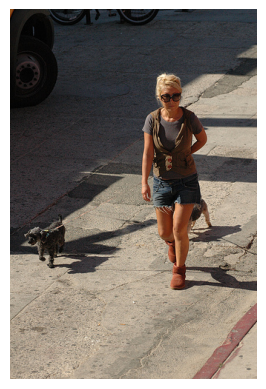

Ground Truths: ['a woman and her two dogs are walking down the street', 'a woman wearing cut off shorts walks down the street with a dog', 'the woman in blue shorts and a brown vest has a black dog to the right of her and a dog behind her', 'the woman is walking her dogs', 'woman and small black dog walking across pavement']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


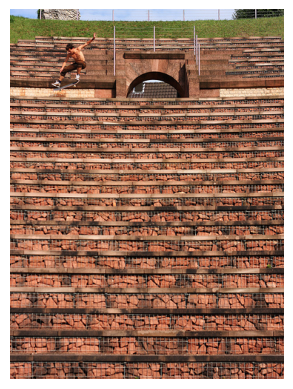

Ground Truths: ['a jogger runs up brick stairs for streght training', 'a man is skating down a set of stairs', 'a skateboarder jumps on brick stairs', 'a young man skateboards around the empty outdoor sports arena', 'the man is skateboarding on a large brick staircase']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


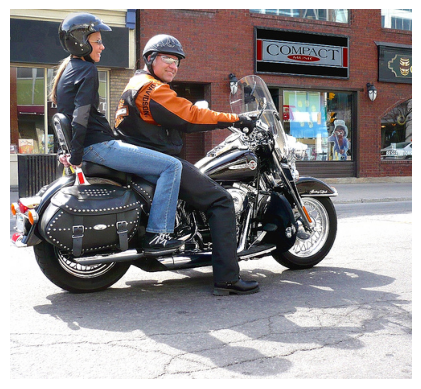

Ground Truths: ['a couple riding a bike', 'a couple riding down the street on a motorcycle', 'a man and woman sitting on a motorcycle', 'a man sits on a motorcycle and a woman is on the back', 'two people ride together on a black motorcycle']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


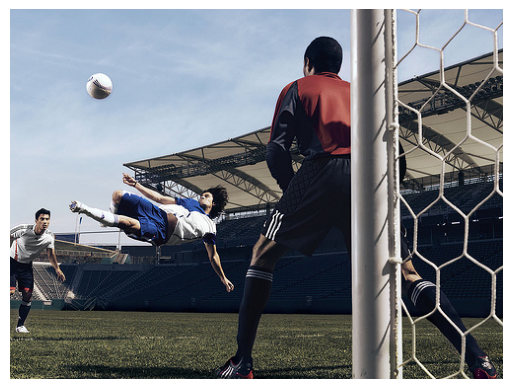

Ground Truths: ['a man is parallel in the air trying to kick the soccer ball past the goalie', 'a soccer player in white attacks the ball with flying kick towards the goal of the player in red as another team member looks on', 'a soccer player is jumping into the air to kick the soccer ball into the goal', 'a soccer player is making a flying kick towards the goal', 'a soccer player leaps sideways in the air to kick the ball']
Keras RNN:     a dog is running through the water
Scratch RNN:   a dog is running through the water
------------------------------------------------------------


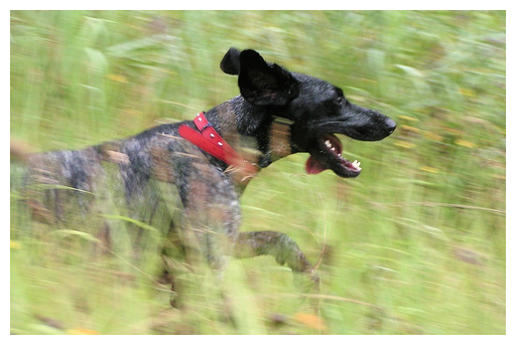

Ground Truths: ['a black and grey dog runs in a field with its tongue hanging out', 'a black dog with a red collar runs through grass', 'a black dog with a red collar walks through the grass with his mouth open and tongue hanging out', 'a dog with a red collar and its tongue hanging out runs through tall grass', 'a dog with red collar is running in the field']
Keras RNN:     a dog is running through the water
Scratch RNN:   a dog is running through the water
------------------------------------------------------------


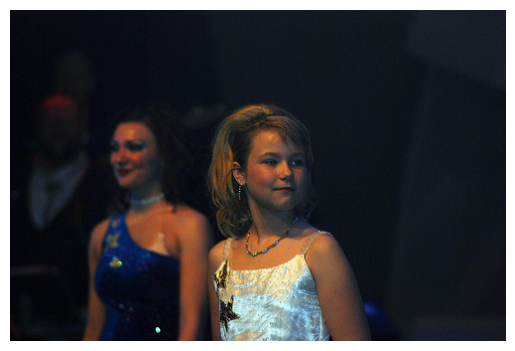

Ground Truths: ['a girl in a white dress walks next to a girl in a blue dress', 'a woman in a white dress and a woman in a blue dress onstage', 'a young girl with makeup and jewelry smiles', 'blonde girl in white top with stars standing beside brunette woman in blue top with stars', 'two teenage girls are wearing fancy dresses at an event']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


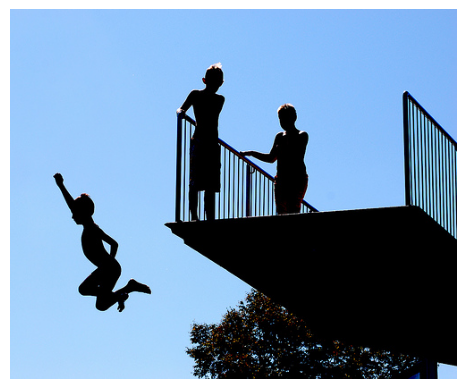

Ground Truths: ['a boy jumps off a platform whilst two other boys stand and watch', 'a child is jumping off a platform into a pool', 'three boys jumping off of a platform', 'three children on diving board with one jumping off', 'two boys standing on top of a diving platform and one captured midair']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


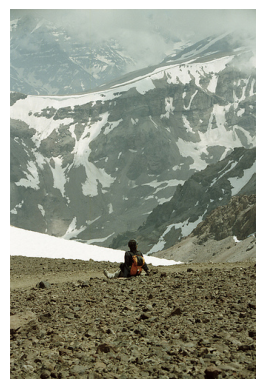

Ground Truths: ['a hiker is sitting on the ground looking towards the snow covered mountains', 'a man is sitting on top of a mountain', 'a person sits near a mountain', 'one person wearing a backpack sitting on the side of a rocky mountain', 'someone is sitting on a hill overlooking a rocky mountain']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


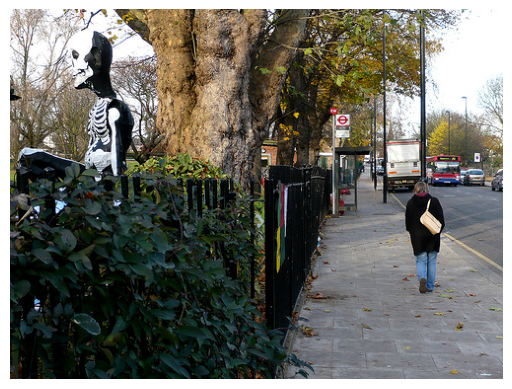

Ground Truths: ['a person is walking on a sidewalk and a skeleton is on the left inside of a fence', 'a skeleton sits on a fence on the edge of a road', 'a skeleton sits on the bushes', 'a woman walks down a sidewalk past a halloween decoration', 'there is a large skeleton behind a fence']
Keras RNN:     a man in a red shirt is standing on a bench
Scratch RNN:   a man in a red shirt is standing on a bench
------------------------------------------------------------


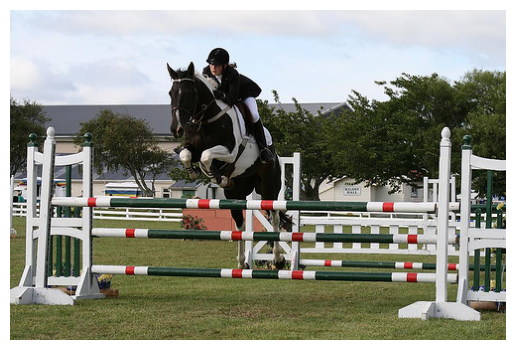

Ground Truths: ['a black horse and its rider are clearing a 3 rung high jump in a competition', 'a horse and rider leap over a striped hurdle', 'a person is riding a horse as it jumps over an obstacle', 'a person jumping a horse over a fence', 'a rider and horse jumping a fence outdoors']
Keras RNN:     a dog is running through the water
Scratch RNN:   a dog is running through the water
------------------------------------------------------------


In [9]:
# Qualitative Analysis (10 Images)
print("\n--- Qualitative Analysis ---")
for img_id in splits['test'][:10]:
    feature = features[features_index[img_id]].reshape(1, -1)
    
    cap_keras = generate_caption_keras(keras_model, tokenizer, feature, tokenizer.max_length)
    cap_scratch = from_scratch_model.generate_caption(feature, tokenizer)
    gt = ground_truth_captions.get(img_id, [])
    
    img_path = os.path.join(data_dir, "images", img_id)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
    print(f"Ground Truths: {gt}")
    print(f"Keras RNN:     {cap_keras}")
    print(f"Scratch RNN:   {cap_scratch}")
    print("-" * 60)

In [10]:
# Variasi Panjang Maksimum Caption
print("\n--- Variasi Panjang Maksimum Caption ---")
max_lengths_to_test = [10, 15, tokenizer.max_length]

for m_len in max_lengths_to_test:
    preds = []
    actuals = []
    
    from_scratch_model.max_length = m_len
    
    for img_id in splits['test'][:100]: # Harus sama dengan jumlah sample di atas
        feature = features[features_index[img_id]].reshape(1, -1)
        cap = from_scratch_model.generate_caption(feature, tokenizer)
        preds.append(cap.split())
        
        gt = ground_truth_captions.get(img_id, [])
        actuals.append([g.split() for g in gt])
        
    bleu = corpus_bleu(actuals, preds, weights=(0.25, 0.25, 0.25, 0.25))
    print(f"Max Length {m_len:>2} -> BLEU-4: {bleu:.4f}")

# Reset
from_scratch_model.max_length = tokenizer.max_length


--- Variasi Panjang Maksimum Caption ---
Max Length 10 -> BLEU-4: 0.1234
Max Length 15 -> BLEU-4: 0.1168
Max Length 38 -> BLEU-4: 0.1168


In [13]:
print("=" * 70)
print("BONUS: RNN BEAM SEARCH EVALUATION (k=3, k=5)")
print("=" * 70)

best_rnn_name = max(results, key=lambda k: results[k]['bleu4'])
best_rnn_config = next(c for c in configs if c['name'] == best_rnn_name)
keras_rnn_best = define_keras_model(
    tokenizer.vocab_size, tokenizer.max_length,
    best_rnn_config['embed_dim'], best_rnn_config['hidden_dim'], best_rnn_config['layers']
)
keras_rnn_best.load_weights(f"../../../weights/captioning/rnn/{best_rnn_config['name']}.weights.h5")
rnn_scratch_best = RNNCaptioner(
    tokenizer.vocab_size, best_rnn_config['embed_dim'],
    best_rnn_config['hidden_dim'], tokenizer.max_length, best_rnn_config['layers']
)
rnn_scratch_best.load_weights_from_keras(keras_rnn_best)
assert hasattr(rnn_scratch_best, 'generate_caption_beam')

beam_subset = splits['test'][:100]
beam_results = {}

for beam_width in [3, 5]:
    preds = []
    actuals = []
    meteors = []

    start_time = time.time()
    for img_id in beam_subset:
        feature = features[features_index[img_id]].reshape(1, -1)
        cap = rnn_scratch_best.generate_caption_beam(feature, tokenizer, beam_width=beam_width)
        preds.append(cap.split())

        gt = ground_truth_captions.get(img_id, [])
        actuals.append([g.split() for g in gt])
        meteors.append(max([meteor_score([g.split()], cap.split()) for g in gt]) if gt else 0)

    elapsed = time.time() - start_time
    bleu4 = corpus_bleu(actuals, preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=SmoothingFunction().method1)
    meteor = float(np.mean(meteors)) if meteors else 0.0
    beam_results[beam_width] = {'bleu4': bleu4, 'meteor': meteor, 'time': elapsed}
    print(f"Beam k={beam_width:<2} | BLEU-4: {bleu4:.4f} | METEOR: {meteor:.4f} | Time: {elapsed:.2f}s")

print("\nBeam search is now testable in the RNN notebook as well.")

BONUS: RNN BEAM SEARCH EVALUATION (k=3, k=5)


Beam k=3  | BLEU-4: 0.1130 | METEOR: 0.2790 | Time: 226.62s
Beam k=5  | BLEU-4: 0.0972 | METEOR: 0.2557 | Time: 225.68s

Beam search is now testable in the RNN notebook as well.
